### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Alan Velasco, Maiccol Zurita, Christopher Rodriguez


**Fecha:** 26/02/20236

### DETECCIÓN DE OUTLIERS

In [10]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.covariance import EllipticEnvelope
import matplotlib.pyplot as plt

In [23]:
# Carga de datos.
import os
os.chdir(r"C:\Users\Usuario\Desktop\Machine 2\Dataset")
print(df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
195 -5.114441  0.646251
196  5.631630  0.277174
197  1.552784  2.348984
198 -0.545507  1.530697
199  1.011772  4.813896

[200 rows x 2 columns]


### 1) EllipticEnvelope()

In [31]:
# Entrenamos un objeto de tipo EllipticEnvelope
algorithm = EllipticEnvelope(support_fraction=None, contamination=0.25, random_state=42)
outlier_method = algorithm.fit(df)

# Aplicamos el método
df_outliers = outlier_method.predict(df)
print(df_outliers)

# Posición de outliers
pos_outliers = np.where(df_outliers == -1)[0]
print('\nOutliers en la posición:\n', pos_outliers)

# Número de outliers
print('\nNúmero de outliers:\n', len(pos_outliers))

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]

Outliers en la posición:
 [150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199]

Número de outliers:
 50


In [25]:
# Función general para detectar outliers
def find_outliers(df, algorithm):
    
    model = algorithm.fit(df)
    df_outliers = model.predict(df)
    pos_outliers = np.where(df_outliers == -1)[0]

    return df_outliers, pos_outliers

### 2) Otros métodos similares

In [26]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# Definición de modelos
IF = IsolationForest(contamination=0.25, random_state=42)
OC_SVM = OneClassSVM(nu=0.25)
LOF = LocalOutlierFactor(contamination=0.25)

# Ejemplo con Isolation Forest
df_outliers, pos_outliers = find_outliers(df, IF)
print(len(pos_outliers))

50


In [27]:
# Eliminamos los outliers
new_df = df[df_outliers == 1]
print(new_df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
145 -0.062437 -0.147900
146 -0.176809  0.254881
147  0.107105 -0.207873
148  0.269880  0.092190
149  0.243859  0.188889

[150 rows x 2 columns]


limite inferior:  -1.0853060827395105
limite superior:  1.0119554520872196
Posición de outliers:  [150 153 154 157 159 160 162 165 168 169 171 172 174 175 177 178 181 184
 185 186 187 190 191 192 193 195 151 152 155 156 161 163 164 166 167 173
 176 179 180 182 188 189 196 197]
Número de outliers:  44


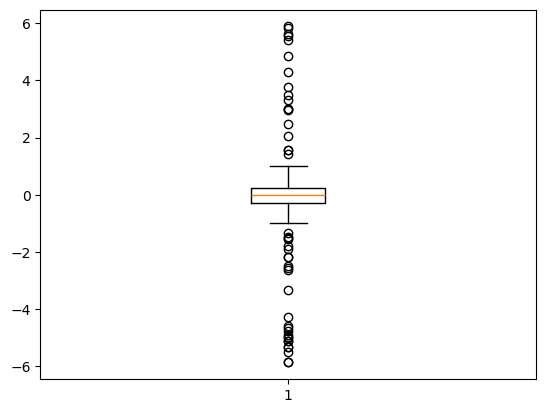

In [28]:
# Seleccionamos el atributo
a = df['a']

# Cálculo de límites
Q1 = stats.scoreatpercentile(a, 25)
Q3 = stats.scoreatpercentile(a, 75)
RIC = Q3 - Q1

li = Q1 - 1.5 * RIC
ls = Q3 + 1.5 * RIC

print('limite inferior: ', li)
print('limite superior: ', ls)

# Posiciones de outliers
pos_i = np.where(a < li)[0]
pos_s = np.where(a > ls)[0]
pos_outliers = np.concatenate((pos_i, pos_s))

print('Posición de outliers: ', pos_outliers)
print('Número de outliers: ', len(pos_outliers))

# Boxplot
plt.boxplot(a)
plt.show()

In [29]:
# Función boxplot
def find_limits_BP(variable):
    
    Q1 = np.percentile(variable, 25)
    Q3 = np.percentile(variable, 75)
    IQR = Q3 - Q1

    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR

    pos_i = np.where(variable < li)[0]
    pos_s = np.where(variable > ls)[0]

    pos_outliers = np.concatenate((pos_i, pos_s))

    return pos_outliers

In [30]:
# Detectar outliers en todas las columnas
headers = df.columns
pos_outliers = []

for i in range(len(headers)):
    variable = df[headers[i]]
    pos_out = np.expand_dims(find_limits_BP(variable), axis=1)
    pos_outliers.append(pos_out)

# Unimos resultados
po = np.vstack(pos_outliers)
pos_out = np.unique(po)

print('Posiciones de outliers: ', pos_out)
print('Numero de outliers: ', len(pos_out))

Posiciones de outliers:  [104 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166
 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184
 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199]
Numero de outliers:  51
